#Telecom X – Parte 2: Predicción de Cancelación (Churn)

##Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.



🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

##Preparación de los Datos

###Extracción del Archivo Tratado
Extracción del Archivo Tratado Carga el archivo CSV que contiene los datos tratados anteriormente.

In [ ]:
import pandas as pd
datos = pd.read_csv('https://raw.githubusercontent.com/fasalgad/TelecomX_LATAM-parte-2/refs/heads/main/datos_tratados.csv')
datos.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


###Eliminación de Columnas Irrelevantes
Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [ ]:
datos.columns

Index(['customerid', 'churn', 'gender', 'seniorcitizen', 'partner',
       'dependents', 'tenure', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'charges_monthly', 'charges_total',
       'cuentas_diarias'],
      dtype='object')

In [ ]:
datos.index

RangeIndex(start=0, stop=7267, step=1)

In [ ]:
if 'customerid' in datos.columns:
    datos = datos.drop(columns=['customerid'])
    print("Columna 'customerid' removida con éxito.")
print(datos.head())

Columna 'customerid' removida con éxito.
  churn  gender  seniorcitizen partner dependents  tenure phoneservice  \
0    No  Female              0     Yes        Yes       9          Yes   
1    No    Male              0      No         No       9          Yes   
2   Yes    Male              0      No         No       4          Yes   
3   Yes    Male              1     Yes         No      13          Yes   
4   Yes  Female              1     Yes         No       3          Yes   

  multiplelines internetservice onlinesecurity  ... deviceprotection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  techsupport streamingtv streamingmovies        contract paperlessbilling  \
0  

In [ ]:
datos.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


###Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [ ]:
datos.sample(2)

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
1466,No,Female,0,No,No,55,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,73.10,4144.9,2.436667
2912,No,Male,0,Yes,No,71,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,105.25,7291.75,3.508333


In [ ]:
datos.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'charges_monthly', 'charges_total', 'cuentas_diarias'],
      dtype='object')

In [ ]:
datos.index

RangeIndex(start=0, stop=7267, step=1)

In [ ]:
datos["churn"] = datos["churn"].map(lambda x: {"Yes":1,"No":0}.get(x, x))

In [ ]:
datos.sample(1)

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
1542,No,Male,0,Yes,Yes,52,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,24.55,1331.05,0.818333


In [ ]:
print(datos.info())
print(datos.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   churn             7267 non-null   int64  
 1   gender            7267 non-null   object 
 2   seniorcitizen     7267 non-null   int64  
 3   partner           7267 non-null   object 
 4   dependents        7267 non-null   object 
 5   tenure            7267 non-null   int64  
 6   phoneservice      7267 non-null   object 
 7   multiplelines     7267 non-null   object 
 8   internetservice   7267 non-null   object 
 9   onlinesecurity    7267 non-null   object 
 10  onlinebackup      7267 non-null   object 
 11  deviceprotection  7267 non-null   object 
 12  techsupport       7267 non-null   object 
 13  streamingtv       7267 non-null   object 
 14  streamingmovies   7267 non-null   object 
 15  contract          7267 non-null   object 
 16  paperlessbilling  7267 non-null   object 


In [ ]:
binary_cols = [
    "partner",
    "dependents",
    "phoneservice",
    "paperlessbilling",
    "churn"
]

for col in binary_cols:
    datos[col] = datos[col].map(lambda x: {"Yes":1,"No":0}.get(x, x))

datos.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,cuentas_diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3,2.186667
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4,1.996667
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.4,2.796667


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "gender",
    "multiplelines",
    "internetservice",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies",
    "contract",
    "paymentmethod"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(datos[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=datos.index
)

datos = pd.concat([datos.drop(columns=categorical_cols), encoded_df], axis=1)

In [ ]:
datos.sample(20)

,churn,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,charges_monthly,charges_total,cuentas_diarias,...,streamingmovies_No,streamingmovies_No internet service,streamingmovies_Yes,contract_Month-to-month,contract_One year,contract_Two year,paymentmethod_Bank transfer (automatic),paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
6690,0,0,0,0,44,1,0,65.40,2774.55,2.180000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2885,0,0,1,1,58,1,1,91.55,5511.65,3.051667,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2996,0,0,0,0,63,1,0,97.45,6253,3.248333,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5257,0,0,1,1,36,1,0,19.20,702.9,0.640000,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
520,0,0,0,1,3,1,0,70.70,225.65,2.356667,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2524,0,0,1,0,32,1,1,75.50,2324.7,2.516667,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6792,0,0,0,0,12,1,0,20.10,223.6,0.670000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2599,0,0,0,0,8,1,0,64.10,504.05,2.136667,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5139,0,1,1,0,29,1,0,90.10,2656.7,3.003333,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3778,0,0,0,0,72,1,1,112.75,8192.6,3.758333,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
datos = datos.drop(columns=[
    "gender_Female",
    "multiplelines_No",
    "internetservice_No",
    "onlinesecurity_No"
])

print(datos.columns)
datos.info()

Index(['churn', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'paperlessbilling', 'charges_monthly', 'charges_total',
       'cuentas_diarias', 'gender_Male', 'multiplelines_No phone service',
       'multiplelines_Yes', 'internetservice_DSL',
       'internetservice_Fiber optic', 'onlinesecurity_No internet service',
       'onlinesecurity_Yes', 'onlinebackup_No',
       'onlinebackup_No internet service', 'onlinebackup_Yes',
       'deviceprotection_No', 'deviceprotection_No internet service',
       'deviceprotection_Yes', 'techsupport_No',
       'techsupport_No internet service', 'techsupport_Yes', 'streamingtv_No',
       'streamingtv_No internet service', 'streamingtv_Yes',
       'streamingmovies_No', 'streamingmovies_No internet service',
       'streamingmovies_Yes', 'contract_Month-to-month', 'contract_One year',
       'contract_Two year', 'paymentmethod_Bank transfer (automatic)',
       'paymentmethod_Credit card (automatic)',
       'paymentm

In [ ]:
datos["charges_total"] = pd.to_numeric(datos["charges_total"], errors="coerce")
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   churn                                    7267 non-null   int64  
 1   seniorcitizen                            7267 non-null   int64  
 2   partner                                  7267 non-null   int64  
 3   dependents                               7267 non-null   int64  
 4   tenure                                   7267 non-null   int64  
 5   phoneservice                             7267 non-null   int64  
 6   paperlessbilling                         7267 non-null   int64  
 7   charges_monthly                          7267 non-null   float64
 8   charges_total                            7256 non-null   float64
 9   cuentas_diarias                          7267 non-null   float64
 10  gender_Male                              7267 no

In [ ]:
datos["charges_total"].isnull().sum()

np.int64(11)

In [ ]:
datos["charges_total"] = datos["charges_total"].fillna(datos["charges_total"].median())

In [ ]:
datos["charges_total"].isnull().sum()

np.int64(0)

###Verificación de la Proporción de Cancelación (Churn)
Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [ ]:
datos["churn"].value_counts()

,count
churn,
0,5398
1,1869


In [ ]:
datos["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.74281
1,0.25719


In [ ]:
churn_proporcion = datos["churn"].value_counts(normalize=True) * 100
churn_proporcion

,proportion
churn,
0,74.280996
1,25.719004


Aproximadamente el 26% de los clientes cancelaron el servicio, mientras que el 74% permanecen activos.
Esto indica un desbalance moderado entre las clases, lo cual puede afectar el desempeño de algunos modelos predictivos, especialmente aquellos sensibles al desbalance de clases.

###Balanceo de Clases
Aplicar técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

In [ ]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

# 1. Separar variables
X = datos.drop("churn", axis=1)
y = datos["churn"]

# 2. Verificar proporción de churn
print("Distribución original:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

# 3. Crear dataframe completo
df = pd.concat([X, y], axis=1)

# Separar clases
mayoria = df[df["churn"] == 0]
minoria = df[df["churn"] == 1]

# 4. Undersampling
mayoria_reducida = resample(
    mayoria,
    replace=False,
    n_samples=len(minoria),
    random_state=42
)

datos_undersample = pd.concat([mayoria_reducida, minoria])

print("\nDistribución con Undersampling:")
print(datos_undersample["churn"].value_counts())

# 5. Oversampling
minoria_aumentada = resample(
    minoria,
    replace=True,
    n_samples=len(mayoria),
    random_state=42
)

datos_oversample = pd.concat([mayoria, minoria_aumentada])

print("\nDistribución con Oversampling:")
print(datos_oversample["churn"].value_counts())

# 6. SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("\nDistribución con SMOTE:")
print(pd.Series(y_smote).value_counts())

Distribución original:
churn
0    5398
1    1869
Name: count, dtype: int64
churn
0    74.280996
1    25.719004
Name: proportion, dtype: float64

Distribución con Undersampling:
churn
0    1869
1    1869
Name: count, dtype: int64

Distribución con Oversampling:
churn
0    5398
1    5398
Name: count, dtype: int64

Distribución con SMOTE:
churn
0    5398
1    5398
Name: count, dtype: int64


##Correlación y Selección de Variables

###Análisis de Correlación
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

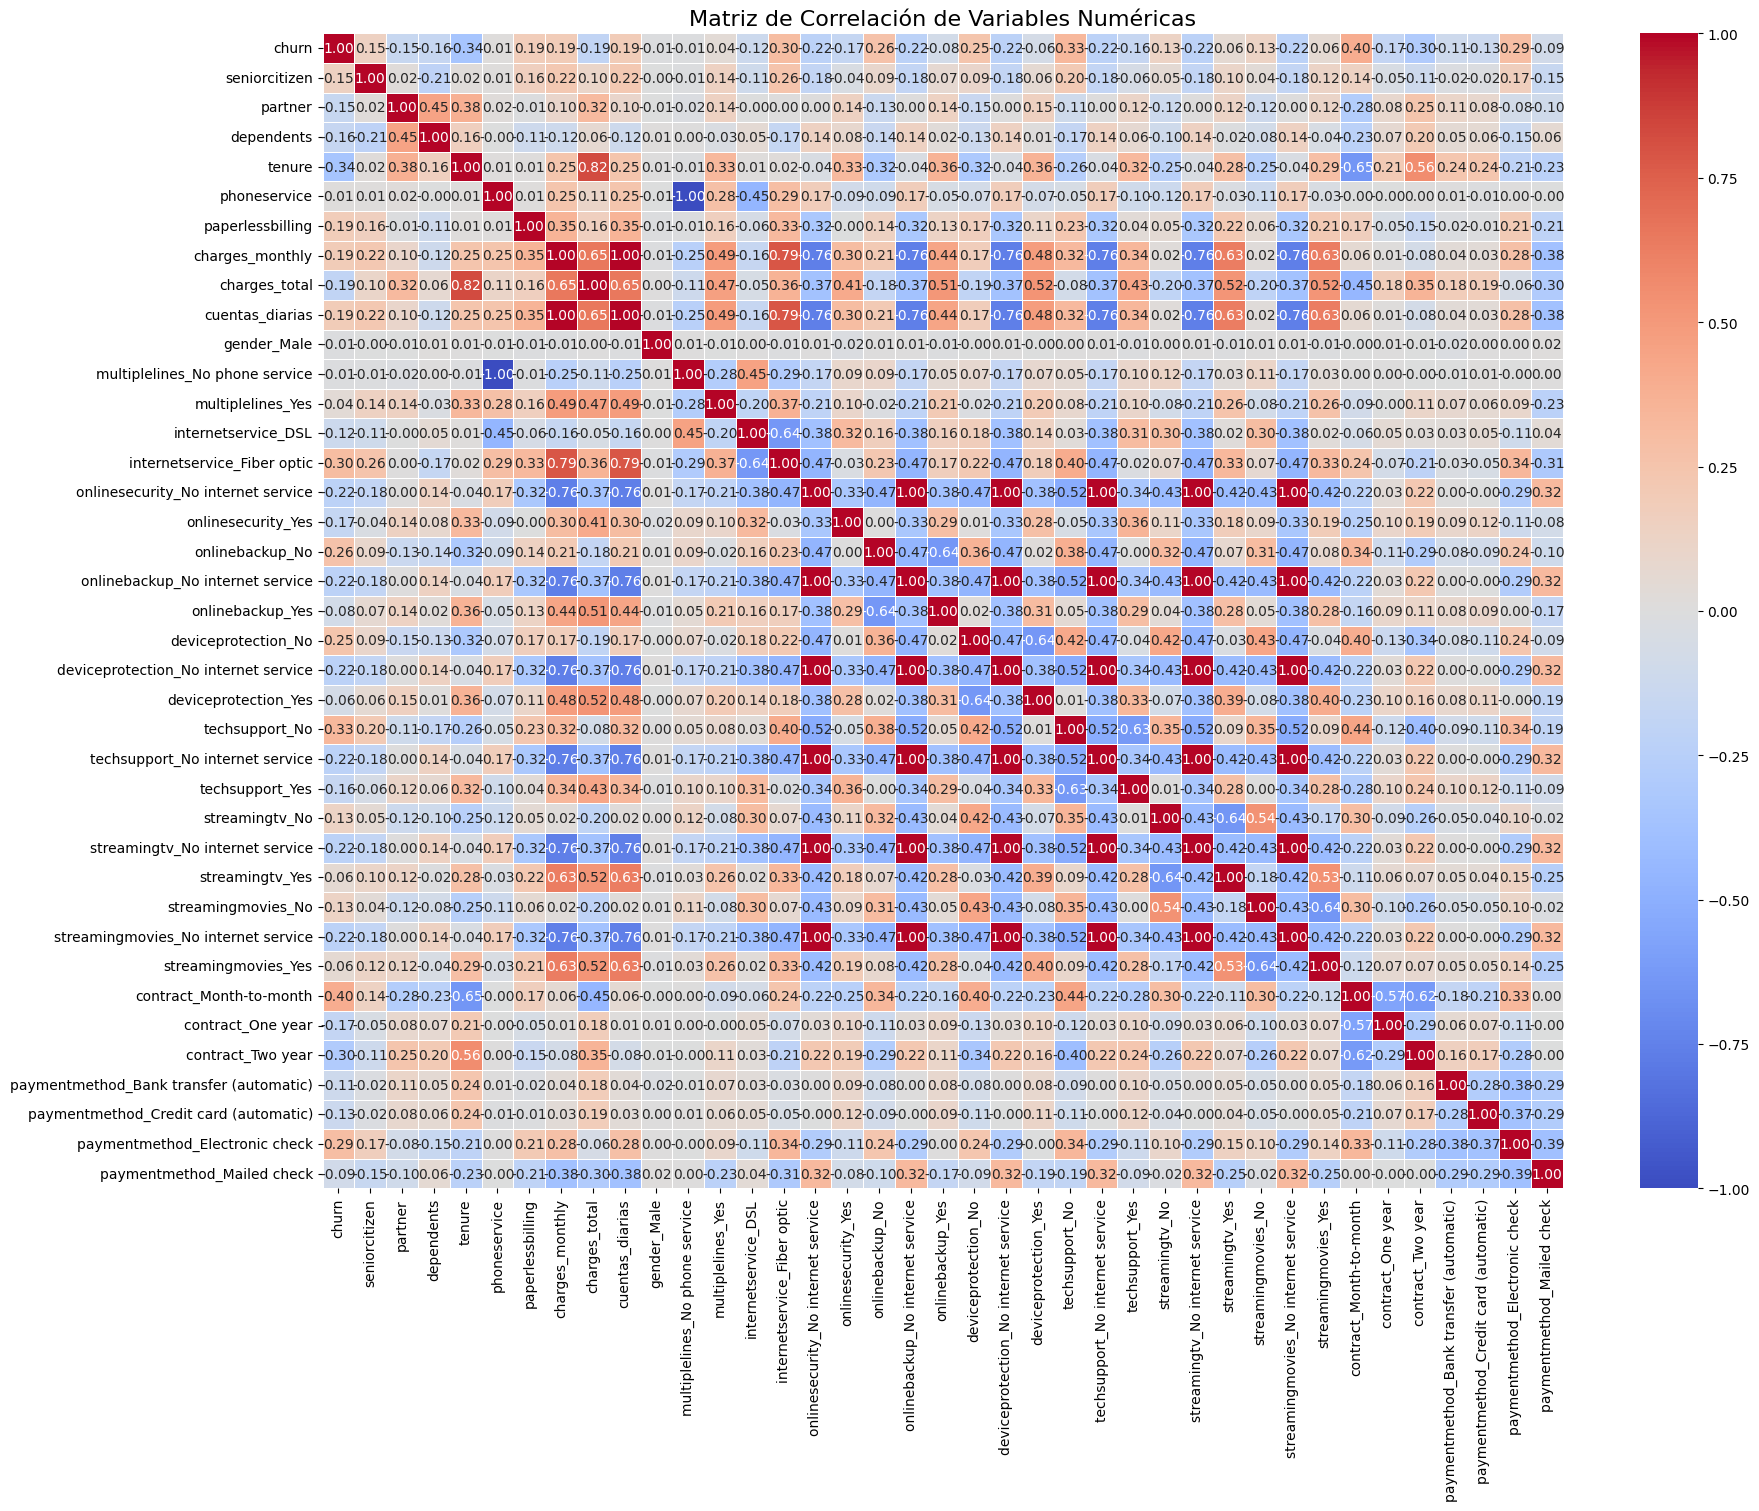


Correlación de las variables con 'churn':
churn                                      1.000000
contract_Month-to-month                    0.395584
techsupport_No                             0.330446
internetservice_Fiber optic                0.300949
paymentmethod_Electronic check             0.294626
onlinebackup_No                            0.263111
deviceprotection_No                        0.246919
cuentas_diarias                            0.189866
charges_monthly                            0.189866
paperlessbilling                           0.186666
seniorcitizen                              0.146733
streamingmovies_No                         0.128721
streamingtv_No                             0.126795
streamingtv_Yes                            0.062430
streamingmovies_Yes                        0.060586
multiplelines_Yes                          0.039343
phoneservice                               0.012571
gender_Male                               -0.009555
multiplelines_No phon

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
corr_matrix = datos.corr(numeric_only=True)

# Visualizar la matriz de correlación
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

# Mostrar las correlaciones con la variable 'churn'
print("\nCorrelación de las variables con 'churn':")
print(corr_matrix['churn'].sort_values(ascending=False))

**Análisis de Correlaciones con Churn**

A continuación se muestran las variables que presentan mayor correlación con **Churn (cancelación de clientes)**. Estas correlaciones ayudan a identificar qué características están más asociadas con la probabilidad de que un cliente abandone el servicio.

---

**Correlaciones Positivas más Fuertes con Churn**

Las siguientes variables tienen una **correlación positiva**, lo que significa que **cuando están presentes, aumenta la probabilidad de que el cliente cancele**.

- **contract_Month-to-month (0.3956)**  
  Los clientes con contratos mensuales tienen una mayor tendencia a cancelar el servicio.

- **techsupport_No (0.3304)**  
  Los clientes que no cuentan con soporte técnico presentan una mayor probabilidad de churn.

- **internetservice_Fiber optic (0.3009)**  
  Los usuarios con servicio de fibra óptica muestran una tendencia más alta a cancelar.

- **paymentmethod_Electronic check (0.2946)**  
  El uso de cheque electrónico como método de pago está asociado con una mayor tasa de cancelación.

- **onlinebackup_No (0.2631)**  
  Los clientes que no tienen servicio de respaldo en línea también muestran una mayor probabilidad de churn.

---

**Correlaciones Negativas más Fuertes con Churn**

Las siguientes variables tienen una **correlación negativa**, lo que indica que **cuando aumentan o están presentes, disminuye la probabilidad de cancelación**.

- **tenure (-0.3441)**  
  Cuanto más tiempo lleva un cliente en la empresa, menor es la probabilidad de que cancele el servicio. Este parece ser uno de los factores más importantes.

- **contract_Two year (-0.2951)**  
  Los clientes con contratos de dos años tienen menos probabilidad de cancelar.

- **Servicios con "No internet service" (~ -0.224)**  
  Variables como:
  - `onlinesecurity_No internet service`
  - `onlinebackup_No internet service`
  - `deviceprotection_No internet service`
  - `techsupport_No internet service`
  - `streamingtv_No internet service`
  - `streamingmovies_No internet service`

  En general indican que los clientes **sin servicio de internet** tienden a cancelar menos. Esto puede tener sentido porque muchos servicios adicionales dependen del internet.

- **charges_total (-0.1940)**  
  A mayor cantidad de cargos totales acumulados, menor probabilidad de cancelación. Esto podría indicar que los clientes con mayor historial de gasto están más comprometidos con el servicio.

---
**Observación General**

En general, parece que los factores más relacionados con el churn están vinculados a:

- **Tipo de contrato**
- **Antigüedad del cliente (tenure)**
- **Disponibilidad de servicios adicionales**
- **Métodos de pago**

Esto sugiere que estrategias como **promover contratos de mayor duración** o **ofrecer más soporte y servicios adicionales** podrían ayudar a reducir la tasa de cancelación.

###Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

- Tiempo de contrato × Cancelación
- Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

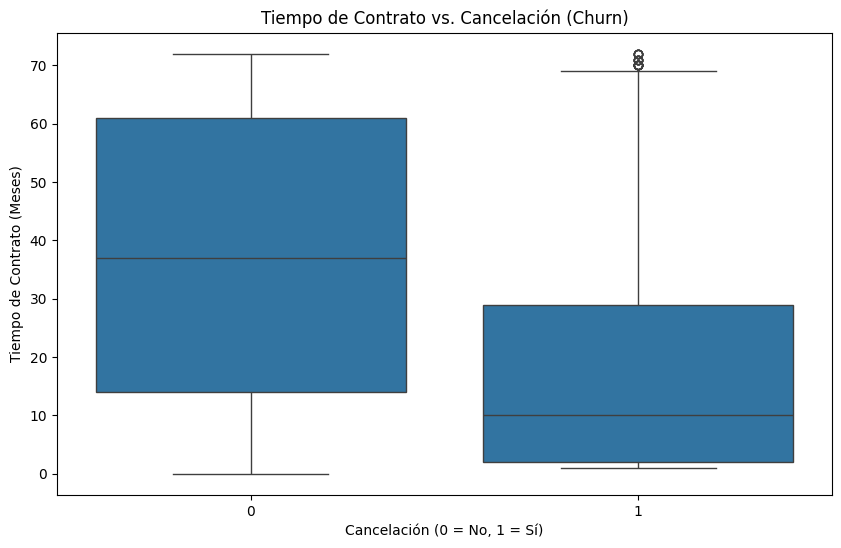

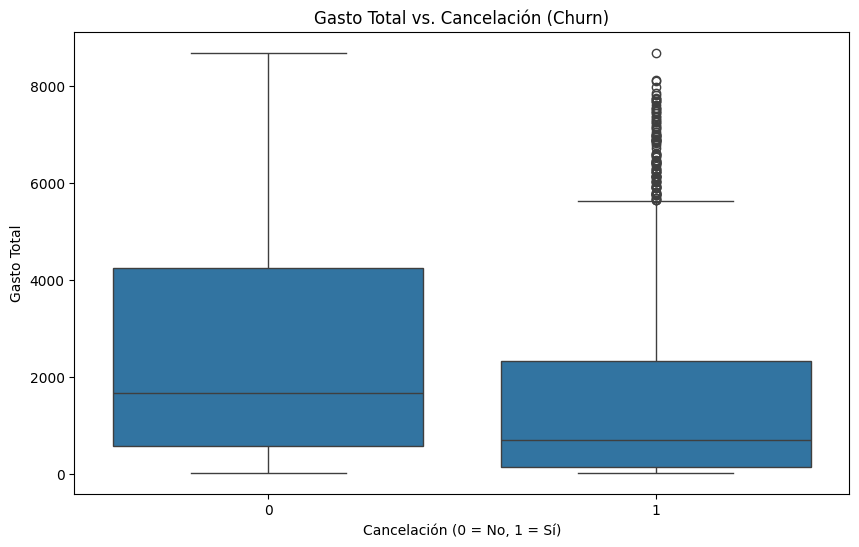

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico: Tiempo de contrato (tenure) vs Cancelación (churn)
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='tenure', data=datos)
plt.title('Tiempo de Contrato vs. Cancelación (Churn)')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Tiempo de Contrato (Meses)')
plt.show()

# Gráfico: Gasto total (charges_total) vs Cancelación (churn)
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='charges_total', data=datos)
plt.title('Gasto Total vs. Cancelación (Churn)')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Gasto Total')
plt.show()

**Análisis de Boxplots: Tenure y Charges Total vs Churn**

Los gráficos de caja (**boxplots**) ya fueron generados para analizar la relación entre algunas variables numéricas y la cancelación de clientes (**churn**). A continuación se describen las principales observaciones obtenidas a partir de estos gráficos.

---

**1. Tiempo de Contrato (Tenure) vs Cancelación (Churn)**

**Clientes que NO cancelan (Churn = 0):**

En el boxplot se observa que estos clientes tienen, en general, una **antigüedad significativamente mayor** en el servicio.  
La **mediana de tenure** para este grupo es considerablemente más alta, lo que indica que estos clientes tienden a permanecer más tiempo con la empresa.

**Clientes que SÍ cancelan (Churn = 1):**

En cambio, los clientes que cancelan presentan un **tiempo de contrato mucho menor**.  
Tanto la **mediana** como el **rango intercuartílico** de `tenure` son más bajos en comparación con el grupo que permanece en el servicio.

Este comportamiento **refuerza la correlación negativa** que se había identificado anteriormente:  
a **menor tiempo de permanencia**, **mayor probabilidad de cancelación**.

---

**2. Gasto Total (Charges Total) vs Cancelación (Churn)**

**Clientes que NO cancelan (Churn = 0):**

Los clientes que permanecen en el servicio presentan, en promedio, un **gasto total acumulado más alto**.  
En el boxplot se puede ver que tanto la **mediana** como la **distribución de `charges_total`** son mayores en este grupo.

**Clientes que SÍ cancelan (Churn = 1):**

Por otro lado, los clientes que cancelan el servicio generalmente tienen un **gasto total acumulado más bajo**.  
Esto sugiere que los clientes con **menor historial de gasto** tienden a abandonar el servicio con mayor frecuencia.

Este resultado también es **consistente con la correlación negativa** observada previamente para esta variable.

---

**Conclusión**

En base a los boxplots analizados, se puede observar que:

- **Tenure** (tiempo de permanencia del cliente) es un factor relevante en la cancelación.
- **Charges_total** (gasto total acumulado) también muestra una relación importante con el churn.

En general, los gráficos muestran que **los clientes con menor tiempo en la empresa y menor gasto acumulado son los que presentan mayor probabilidad de cancelar el servicio**.

## Modelado Predictivo

###Separación de Datos
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [26]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = datos.drop('churn', axis=1)
y = datos['churn']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Proporción de Churn en y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Proporción de Churn en y_test:\n{y_test.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (5813, 38)
Tamaño del conjunto de prueba (X_test): (1454, 38)
Proporción de Churn en y_train:
churn
0    0.742818
1    0.257182
Name: proportion, dtype: float64
Proporción de Churn en y_test:
churn
0    0.742779
1    0.257221
Name: proportion, dtype: float64


**División del Dataset en Conjuntos de Entrenamiento y Prueba**

El dataset fue dividido correctamente en conjuntos de **entrenamiento** y **prueba**, con el objetivo de poder entrenar los modelos y posteriormente evaluar su desempeño con datos que no fueron utilizados durante el entrenamiento.

**Conjunto de Entrenamiento (X_train, y_train)**  
Este conjunto contiene **5813 registros**, lo que corresponde aproximadamente al **80% del total de los datos**.  
Estos datos serán utilizados para **entrenar los modelos de machine learning**.

**Conjunto de Prueba (X_test, y_test)**  
El conjunto de prueba contiene **1454 registros**, lo que representa el **20% restante del dataset**.  
Este conjunto se utiliza para **evaluar el desempeño del modelo** una vez que ya ha sido entrenado.

**Estratificación de la Variable Churn**

Durante la división del dataset se utilizó el parámetro **`stratify=y`**, lo que permite **mantener la misma proporción de la variable objetivo (churn)** en ambos conjuntos.

En el dataset, la distribución de churn es la siguiente:

- **Churn = 0:** 74.28%  
- **Churn = 1:** 25.72%

Gracias a la estratificación, **estas proporciones se mantienen tanto en el conjunto de entrenamiento como en el de prueba**.

Esto es importante porque el dataset presenta **desbalance de clases**, y conservar la misma distribución ayuda a **entrenar modelos más robustos y obtener evaluaciones más representativas del rendimiento real del modelo**.